In [2]:
from config_file import *
sys.path.append('/export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/problems')
from train import *
import pandas as pd

In [3]:
print_problem()

# Load and preprocess the data
# Load the label data
labels = pd.read_csv(DATA_DIR + '/fusion_labels.csv')
# Load tabular data and remove unnecessary columns for model input
tab = pd.read_csv(DATA_DIR + '/tab_data.csv')
tab.drop(columns=['A', 'B', 'C', 'id', 'Feature14', 'Feature13', 'Feature12', 'Feature11', 'Feature10'], inplace=True)
# Combine the tabular data and labels into a single DataFrame for training
data = pd.concat([tab, labels], axis=1)
# Apply a transformation to create a new target column 'y'
data['y'] = get_y(data, 'fusion')

seed = set_seed(SEED) # Set the random seed for reproducibility
nas = {"img_fts": IMG_FTS, "tab_fts": TAB_FTS}
print(nas)

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_comp_comp ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False
{'img_fts': 2, 'tab_fts': 2}


In [4]:
model = multifix_net_test(nas, OUT_SIZE)
loss_fn = nn.BCELoss()

In [5]:
# Split data into training and testing folds
for i, (train_idx, test_idx) in enumerate(split_data(data, seed)):
    if i == BEST_FOLD:
        train_loader, val_loader, test_loader = get_dataloaders(data, train_idx, test_idx, seed)
        #model, loss_fn = initialise_model(i, nas, True) # initialise the model according to prediction type and training procedure
        wts_dir = save_dir = '/export/scratch2/ima/MultiFIX_GECCO25_code' + MODEL_DIR[1:] + INPUT + '_' + TRAINING + '_' + WTS + '_Freeze_' + str(TEMP_FREEZE) + '.pth'
        model.load_state_dict(torch.load(wts_dir), strict=False)
        loss, auroc, bacc = eval_model(model, test_loader, loss_fn)  # Evaluate the model
        break

In [6]:
# Check Evaluation Metrics
print("*** BEST FOLD METRICS ***")
print("* Loss = ", loss)
print("* AUROC = ", auroc)
print("* BAcc = ", bacc)

*** BEST FOLD METRICS ***
* Loss =  0.0554846932401415
* AUROC =  0.9979707792207793
* BAcc =  0.9898538961038961


# Generate Image Explanations with Grad-CAM

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2  # If not installed, install using 'pip install opencv-python'

iterator = iter(test_loader)

In [8]:
# create df to save values
df = pd.DataFrame(columns=['circle','rectangle','triangle','I1','I2'])

In [11]:
data

,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,id,circle,rectangle,triangle,A,B,C,y
0,0.548814,0.715189,0.602763,0.544883,0.423655,0.645894,0.437587,0.891773,0.963663,0.383442,0,0,1,1,1,1,1,0
1,0.087129,0.020218,0.832620,0.778157,0.870012,0.978618,0.799159,0.461479,0.780529,0.118274,1,0,1,1,0,1,1,0
2,0.264556,0.774234,0.456150,0.568434,0.018790,0.617635,0.612096,0.616934,0.943748,0.681820,2,1,1,1,0,0,1,1
3,0.670638,0.210383,0.128926,0.315428,0.363711,0.570197,0.438602,0.988374,0.102045,0.208877,3,1,1,0,0,0,1,1
4,0.158970,0.110375,0.656330,0.138183,0.196582,0.368725,0.820993,0.097101,0.837945,0.096098,4,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.054575,0.301264,0.247715,0.601280,0.207075,0.010681,0.153854,0.361934,0.803469,0.846918,995,1,1,1,0,0,0,1
996,0.443282,0.965475,0.258111,0.639441,0.853539,0.246301,0.022010,0.437026,0.511874,0.216041,996,0,1,0,1,1,0,0
997,0.413871,0.151172,0.968430,0.451004,0.334551,0.769954,0.802038,0.091648,0.087336,0.088578,997,1,1,1,1,0,0,0
998,0.526672,0.829211,0.366857,0.791279,0.833582,0.235705,0.990239,0.724166,0.049700,0.164453,998,1,1,1,1,1,1,1


In [12]:
for i in range(len(test_loader)-1):
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # Register hooks in the layer of interest
    target_layer = model.img_c_block.resnet.layer4[-1]
    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = model.img_c_block(*model_input).size(1)

    y_pred = model(*model_input).detach().cpu()
    a_c_pred = model.img_c_block(*model_input).detach().cpu()
    a_t_pred = model.img_t_block(*model_input).detach().cpu()
    b_pred = model.tab_a_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    c = a[0,0].detach().numpy()
    r = a[0,1].detach().numpy()
    t = a[0,2].detach().numpy()
    new_row = {'circle': c, 'rectangle': r, 'triangle':t,'I1': a_c_pred[0],'I2': a_t_pred[0]}
    new_row = pd.DataFrame([new_row])
    df = pd.concat([df, new_row], ignore_index=True)
    
    if i < 30:
        # Print results
        print(f"Y = {label}")
        print(f"Y_pred = {y_pred}")
        print(f"IMG_PRED -> {a_pred}")
        print(f"TAB_PRED -> {b_pred}")
        print(f"T1 > T2: {t1} > {t2}")

        # Visualize the original image and the heatmap
        plt.subplot(1, num_classes+1, 1)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
        #plt.title('INPUT')
        plt.axis('off')
        
        for cls in range(num_classes):
            #print(f"Generating Grad-CAM for feature {cls + 1} of {num_classes}...")

            # Register hooks
            backward_handle = target_layer.register_full_backward_hook(backward_hook)
            forward_handle = target_layer.register_forward_hook(forward_hook)

            # Forward pass to get the activations and output
            model_output = model.img_c_block(*model_input)

            # Select the output for the specific class (image feature)
            class_output = model_output[:, cls]

            # Backward pass to calculate gradients for the selected class
            model.zero_grad()  # Clear previous gradients
            class_output.mean().backward()

            # Compute Grad-CAM
            # Pool the gradients across the channels (global average pooling)
            pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

            # Weight the activations by the pooled gradients
            weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
            for i in range(weighted_activations.size(1)):
                weighted_activations[:, i, :, :] *= pooled_gradients[i]


            class_score = class_output.sum().detach().cpu().numpy()  # Get the class score
            # Average the channels to get the heatmap
            heatmap = torch.mean(weighted_activations, dim=1).squeeze()

            # Apply ReLU to the heatmap
            heatmap = F.relu(heatmap)
            
            # Multiply by class score to downscale weak contributions
            heatmap = heatmap.detach().cpu().numpy()

            # Normalize heatmap between 0 and 1 for visualization
            heatmap -= np.min(heatmap)
            if np.max(heatmap) == 0:
                heatmap *= 0
            else: heatmap /= np.max(heatmap)
            
            # Weight heatmap by class score for consistent comparison
            heatmap = heatmap * class_score

            # Resize heatmap to match input image size
            heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

            plt.subplot(1, num_classes+1, cls+2)
            plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
            plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
            #plt.title(f"#{cls + 1}")
            plt.axis('off')

        #plt.suptitle(f"Grad-CAM for Image {i + 1}")
        plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


Y = [[1]]
Y_pred = tensor([[0.9874]])


NameError: name 'a_pred' is not defined

In [18]:
df['I1'] = df['I1'].astype('float')
df['I2'] = df['I2'].astype('float')
df

,circle,rectangle,triangle,I1,I2
0,0,0,0,0.835126,0.977109
1,0,0,1,0.594449,0.692237
2,1,1,1,0.655676,0.533717
3,0,1,0,0.930222,0.993114
4,1,1,1,0.934836,0.488223
...,...,...,...,...,...
194,0,0,1,0.483119,0.665191
195,0,1,1,0.364892,0.499368
196,0,1,1,0.565632,0.687041
197,0,0,0,0.760224,0.958277


In [19]:
pd.set_option('display.max_rows', None)

In [20]:
a  = df.loc[df['I1'] > 0.19]
print(a.shape[0])
print(np.sum(a['circle']))
print(np.sum(a['circle'])/a.shape[0])

199
103
0.5175879396984925


In [21]:
a  = df.loc[df['I1'] > 0.19]

In [22]:
#df.loc[df['I2'] < 0.32]
df.loc[df['I1'] > 0.19]

,circle,rectangle,triangle,I1,I2
0,0,0,0,0.835126,0.977109
1,0,0,1,0.594449,0.692237
2,1,1,1,0.655676,0.533717
3,0,1,0,0.930222,0.993114
4,1,1,1,0.934836,0.488223
5,1,0,0,0.985356,0.611278
6,0,1,0,0.809455,0.946062
7,0,1,0,0.775661,0.958739
8,1,0,0,0.983852,0.617386
9,0,1,0,0.842822,0.978198


In [23]:
df.to_csv('img_fts.csv')

In [24]:
df['tag'] = 2*df['circle'] + df['triangle']#df['rectangle'] + 4*df['circle'] + 2*df['triangle']
df

,circle,rectangle,triangle,I1,I2,tag
0,0,0,0,0.835126,0.977109,0
1,0,0,1,0.594449,0.692237,1
2,1,1,1,0.655676,0.533717,3
3,0,1,0,0.930222,0.993114,0
4,1,1,1,0.934836,0.488223,3
5,1,0,0,0.985356,0.611278,2
6,0,1,0,0.809455,0.946062,0
7,0,1,0,0.775661,0.958739,0
8,1,0,0,0.983852,0.617386,2
9,0,1,0,0.842822,0.978198,0


In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

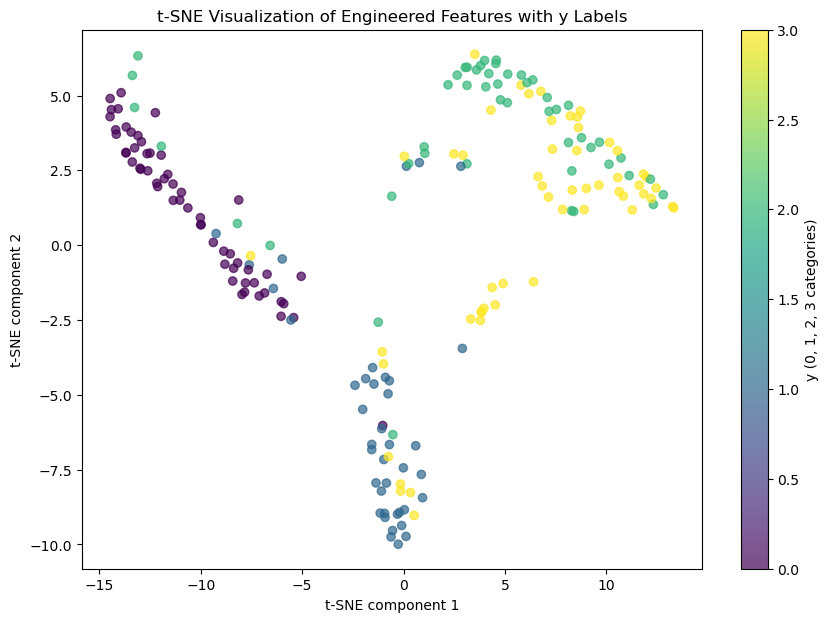

*** LEGEND ***
C | T | TAG
0 | 0 | 0
0 | 1 | 1
1 | 0 | 2
1 | 1 | 3


In [26]:
# Assuming df is your DataFrame with features 'I1', 'I2', 'I3' and you have a separate y array
# Extract the engineered features for t-SNE
features = df[['I1', 'I2']]

# Apply t-SNE with 2 components for visualization
tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(features)

# Add t-SNE results to DataFrame for easy plotting
df['tsne-2d-one'] = tsne_results[:, 0]
df['tsne-2d-two'] = tsne_results[:, 1]

# Assume y is your array with values 0, 1, 2, or 3
# Add y to DataFrame if it's not already there

# Plot the t-SNE results, coloring by the categories in y
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['tsne-2d-one'], df['tsne-2d-two'], 
                      c=df['tag'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='y (0, 1, 2, 3 categories)')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.title('t-SNE Visualization of Engineered Features with y Labels')
plt.show()

print("*** LEGEND ***")
print("C | T | TAG")
print("0 | 0 | 0")
print("0 | 1 | 1")
print("1 | 0 | 2")
print("1 | 1 | 3")

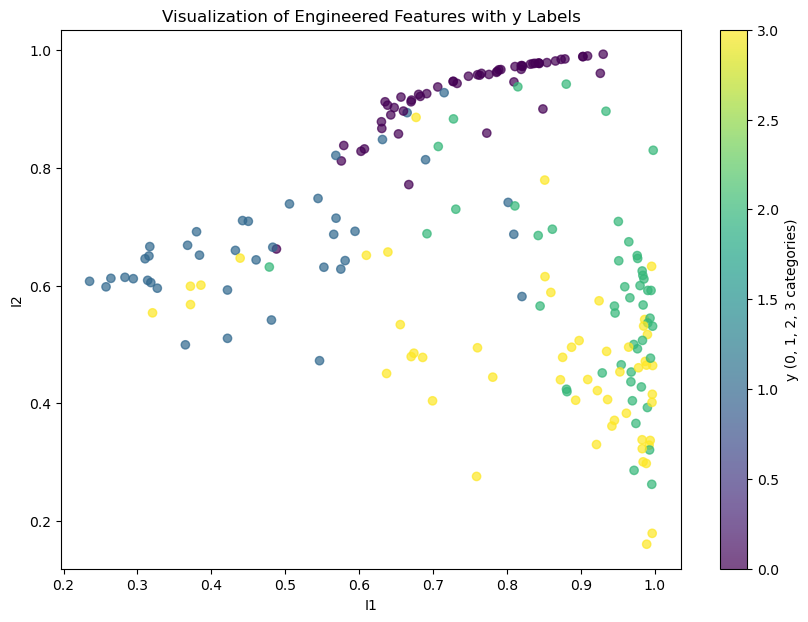

*** LEGEND ***
C | T | TAG
0 | 0 | 0 - purple
0 | 1 | 1 - blue
1 | 0 | 2 - green
1 | 1 | 3 - yellow


In [28]:
# Assuming df is your DataFrame with features 'I1', 'I2', 'I3' and you have a separate y array
# Extract the engineered features for t-SNE
features = df[['I1', 'I2']]

# Apply t-SNE with 2 components for visualization
tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(features)

# Add t-SNE results to DataFrame for easy plotting
df['tsne-2d-one'] = df['I1']
df['tsne-2d-two'] = df['I2']

# Assume y is your array with values 0, 1, 2, or 3
# Add y to DataFrame if it's not already there

# Plot the t-SNE results, coloring by the categories in y
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['tsne-2d-one'], df['tsne-2d-two'], 
                      c=df['tag'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='y (0, 1, 2, 3 categories)')
plt.xlabel('I1')
plt.ylabel('I2')
plt.title('Visualization of Engineered Features with y Labels')
plt.show()

print("*** LEGEND ***")
print("C | T | TAG")
print("0 | 0 | 0 - purple")
print("0 | 1 | 1 - blue")
print("1 | 0 | 2 - green")
print("1 | 1 | 3 - yellow")

/tmp/ipykernel_1814530/2450364457.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = get_cmap('viridis')


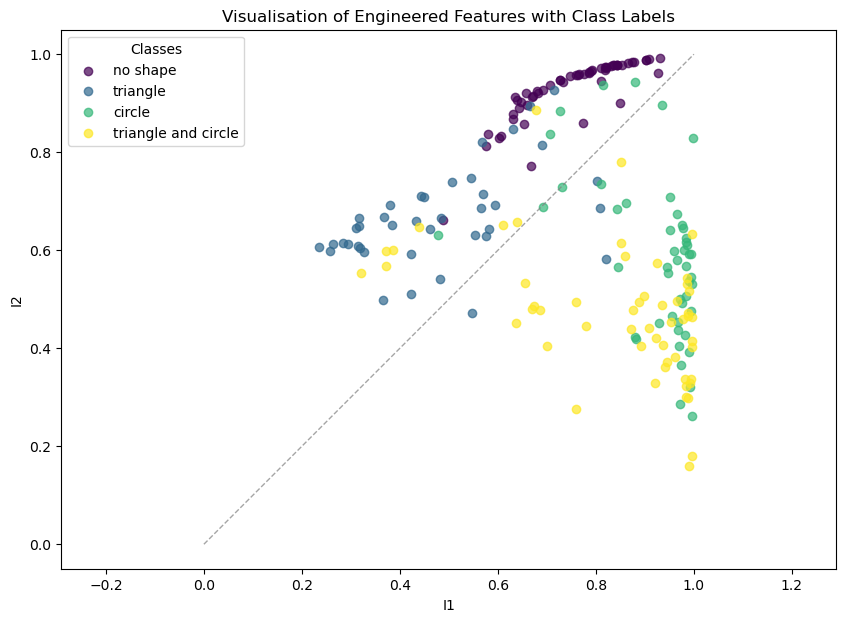

*** LEGEND ***
C | T | TAG
0 | 0 | 0 - purple
0 | 1 | 1 - blue
1 | 0 | 2 - green
1 | 1 | 3 - yellow


In [52]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import numpy as np

# Get the viridis colormap
viridis = get_cmap('viridis')
classes = ['no shape', 'triangle', 'circle', 'triangle and circle']

# Assuming df['tag'] contains the class labels (0, 1, 2, 3)
unique_classes = sorted(df['tag'].unique())  # Get unique class labels (e.g., [0, 1, 2, 3])

# Map each unique class to a color in the viridis colormap
colors = viridis(np.linspace(0, 1, len(unique_classes)))
color_mapping = {label: colors[i] for i, label in enumerate(unique_classes)}

# Plot the scatter plot
plt.figure(figsize=(10, 7))

i = 0
for label, color in color_mapping.items():
    # Filter data for the current class
    class_data = df[df['tag'] == label]
    plt.scatter(class_data['tsne-2d-one'], 
                class_data['tsne-2d-two'], 
                color=color, 
                label=classes[i], 
                alpha=0.7)
    i+=1
    
# Add a subtle diagonal line where I1 = I2
plt.plot([0, 1.0], [0, 1.0], color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.xlabel('I1')
plt.ylabel('I2')
plt.title('Visualisation of Engineered Features with Class Labels')

# Set axis limits to [0, 1.0]
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)

# Ensure the plot has the same scale for both axes
plt.axis('equal')

# Move the legend outside the plot
plt.legend(title="Classes", loc='upper left')#, bbox_to_anchor=(1.05, 0.5))


# Display the plot
plt.show()

print("*** LEGEND ***")
print("C | T | TAG")
print("0 | 0 | 0 - purple")
print("0 | 1 | 1 - blue")
print("1 | 0 | 2 - green")
print("1 | 1 | 3 - yellow")
